In [3]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Carga de los datos en bruto
data=pd.read_csv("../Datos en bruto/Virus del Nilo/ECDC_surveillance_data_West_Nile_virus_infection.csv", sep=",")
data

,HealthTopic,Population,Indicator,Unit,Time,RegionCode,RegionName,NumValue,TxtValue
0,West Nile virus infection,All cases,Reported cases,N,2008-01,AT,Austria,0.000000000,NaN
1,West Nile virus infection,All cases,Reported cases,N,2008-01,BE,Belgium,0.000000000,NaN
2,West Nile virus infection,All cases,Reported cases,N,2008-01,BG,Bulgaria,0.000000000,NaN
3,West Nile virus infection,All cases,Reported cases,N,2008-01,CY,Cyprus,0.000000000,NaN
4,West Nile virus infection,All cases,Reported cases,N,2008-01,CZ,Czechia,0.000000000,NaN
...,...,...,...,...,...,...,...,...,...
6669,West Nile virus infection,All cases,Reported cases,N,2023-12,RS,Serbia,2.000000000,NaN
6670,West Nile virus infection,All cases,Reported cases,N,2023-12,SE,Sweden,0.000000000,NaN
6671,West Nile virus infection,All cases,Reported cases,N,2023-12,SI,Slovenia,0.000000000,NaN
6672,West Nile virus infection,All cases,Reported cases,N,2023-12,SK,Slovakia,0.000000000,NaN


In [13]:
nilo_IT=data[(data.Indicator=='Reported cases') & (data.RegionName=='Italy')]
nilo_IT

,HealthTopic,Population,Indicator,Unit,Time,RegionCode,RegionName,NumValue,TxtValue
16,West Nile virus infection,All cases,Reported cases,N,2008-01,IT,Italy,0.000000000,NaN
45,West Nile virus infection,All cases,Reported cases,N,2008-02,IT,Italy,0.000000000,NaN
74,West Nile virus infection,All cases,Reported cases,N,2008-03,IT,Italy,0.000000000,NaN
103,West Nile virus infection,All cases,Reported cases,N,2008-04,IT,Italy,0.000000000,NaN
132,West Nile virus infection,All cases,Reported cases,N,2008-05,IT,Italy,0.000000000,NaN
...,...,...,...,...,...,...,...,...,...
6500,West Nile virus infection,All cases,Reported cases,N,2023-08,IT,Italy,183.000000000,NaN
6539,West Nile virus infection,All cases,Reported cases,N,2023-09,IT,Italy,75.000000000,NaN
6578,West Nile virus infection,All cases,Reported cases,N,2023-10,IT,Italy,18.000000000,NaN
6617,West Nile virus infection,All cases,Reported cases,N,2023-11,IT,Italy,4.000000000,NaN


In [14]:
nilo_IT['Time'] = pd.to_datetime(nilo_IT['Time'])
nilo_IT['NumValue'] = pd.to_numeric(nilo_IT['NumValue'])

In [15]:
nilo_IT=nilo_IT.loc[:,['NumValue','Time']]
nilo_IT.set_index('Time', inplace=True)
nilo_IT

,NumValue
Time,
2008-01-01,0.0
2008-02-01,0.0
2008-03-01,0.0
2008-04-01,0.0
2008-05-01,0.0
...,...
2023-08-01,183.0
2023-09-01,75.0
2023-10-01,18.0


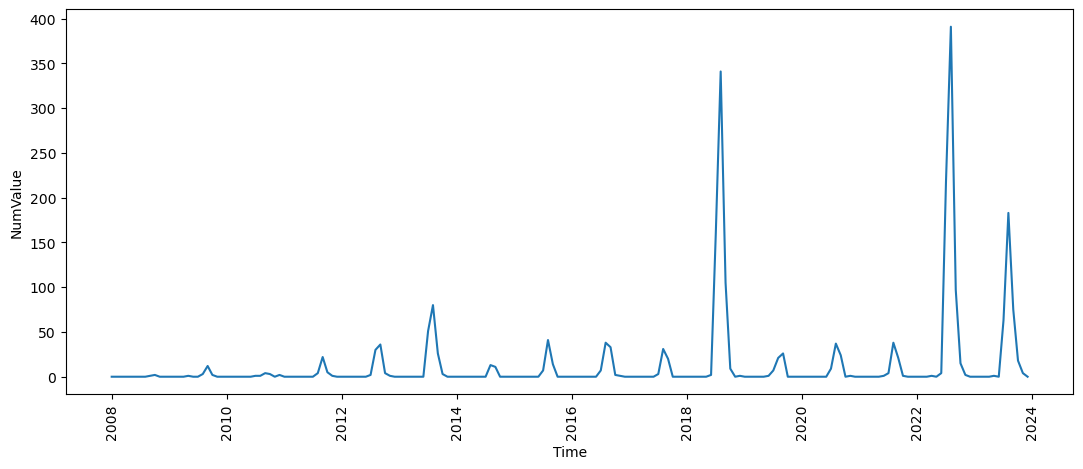

In [16]:
plt.figure(figsize=(13,5))
sns.lineplot(data=nilo_IT,x=nilo_IT.index,y=nilo_IT.NumValue)
plt.xticks(rotation=90)
plt.show()

In [17]:
#Exportamos los datos relativos al virus del Nilo en Italia
nilo_IT.to_csv('nilo_it_indexado.csv',index=True,encoding='utf-8')